In [1]:
from helpers import *
import numpy as np
from pandas import DataFrame, concat
import pandas as pd
from IPython.display import display, Markdown

In [2]:
# 품질 점검 완료 데이터 셋 가져오기
origin = pd.read_excel("local_qtcheck.xlsx")
num_desc = pd.read_excel("local_numerical_qtcheck.xlsx", index_col=0)
cat_desc = pd.read_excel("local_categorical_qtcheck.xlsx", index_col=0)


In [3]:
# 타입 변환(명목형 확정)
df3 = my_qtcheck.set_type(origin, as_category=cat_desc.columns)

<class 'pandas.DataFrame'>
RangeIndex: 6240 entries, 0 to 6239
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   기준월           6240 non-null   category
 1   행정동코드         6240 non-null   int64   
 2   매출금액          6240 non-null   int64   
 3   행정구역          6240 non-null   str     
 4   총인구수          6240 non-null   int64   
 5   월유동인구수        6240 non-null   float64 
 6   년도            6240 non-null   category
 7   가맹점수_소매       6240 non-null   int64   
 8   가맹점수_숙박       6240 non-null   int64   
 9   가맹점수_음식       6240 non-null   int64   
 10  가맹점수_부동산      6240 non-null   int64   
 11  가맹점수_과학·기술    6240 non-null   int64   
 12  가맹점수_시설관리·임대  6240 non-null   int64   
 13  가맹점수_교육       6240 non-null   int64   
 14  가맹점수_보건의료     6240 non-null   int64   
 15  가맹점수_예술·스포츠   6240 non-null   int64   
 16  가맹점수_수리·개인    6240 non-null   int64   
 17  가맹점수_기타       6240 non-null   int64   
dtypes: category(2), flo

In [4]:
# 위경도 데이터 불러오기
coord = pd.read_csv(
    "경기도_행정동_중심점.csv",
    encoding="utf-8",
    dtype={"ADM_CD": str}
)

coord.head()

,X,Y,BASE_DATE,ADM_CD,ADM_NM
0,126.989378,37.320531,20250630,31011540,파장동
1,126.971753,37.299592,20250630,31011550,율천동
2,126.989323,37.304703,20250630,31011560,정자1동
3,126.998383,37.292271,20250630,31011570,정자2동
4,127.013579,37.291219,20250630,31011580,영화동


### 월별 자료를 행정동별 특성으로 요약

- 지역 유형화의 단위를 행정동으로 맞추기 위해 인구·유동인구는 분석 기간의 월평균으로 요약했다.
- 가맹점 수는 같은 연도에 반복된 월별 행을 제거한 뒤 3개년을 동일한 비중으로 평균했다. 관측 월이 많은 2024년이 가맹점 프로파일에서 더 큰 비중을 차지하지 않도록 한 구성이다.
- 인구 대비 지표는 이렇게 요약한 값으로 다시 계산한다. 따라서 월별 비율을 단순 평균한 값과는 계산 기준이 다르다.
- 평균매출은 군집 형성 이후 유형별 매출을 비교하기 위한 정보이며, 실제 군집 입력에는 포함되지 않는다.

In [5]:
# 지역화폐 데이터셋 불러오기
df_area = pd.read_excel(
    "local_data.xlsx"
)

df_area.head()

,기준월,행정동코드,매출금액,행정구역,총인구수,월유동인구수,년도,가맹점수_소매,가맹점수_숙박,가맹점수_음식,...,가맹점수_과학·기술,가맹점수_시설관리·임대,가맹점수_교육,가맹점수_보건의료,가맹점수_예술·스포츠,가맹점수_수리·개인,가맹점수_기타,1인당_유동인구,총_가맹점수,만명당_가맹점수
0,7,4111156000,41128684,경기도 수원시 장안구 파장동,22480,241011.94,2023,274,3,248,...,6,4,14,21,25,97,19,10.721172,712,316.725979
1,8,4111156000,5115679,경기도 수원시 장안구 파장동,22451,241268.02,2023,274,3,248,...,6,4,14,21,25,97,19,10.746426,712,317.135094
2,9,4111156000,436318,경기도 수원시 장안구 파장동,22410,236580.40,2023,274,3,248,...,6,4,14,21,25,97,19,10.556912,712,317.715306
3,10,4111156000,631469,경기도 수원시 장안구 파장동,23628,268762.16,2023,274,3,248,...,6,4,14,21,25,97,19,11.374732,712,301.337396
4,11,4111156000,591386,경기도 수원시 장안구 파장동,24542,253510.66,2023,274,3,248,...,6,4,14,21,25,97,19,10.329666,712,290.114905


In [6]:
# 위경도 데이터 불러오기
code = pd.read_excel(
    "adm_code.xls"
)

code.head()

,2025년6월 행정구역 코드,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5
0,시도코드,시도명칭,시군구코드,시군구명칭,읍면동코드,읍면동명칭
1,11,서울특별시,010,종로구,530,사직동
2,11,서울특별시,010,종로구,540,삼청동
3,11,서울특별시,010,종로구,550,부암동
4,11,서울특별시,010,종로구,560,평창동


In [7]:
# 행정동 groupby
origin = df_area.copy()
origin = origin.drop(columns=['기준월', '년도'])

origin['1인당_유동인구'] = origin['월유동인구수'] / origin['총인구수']

origin['총_가맹점수'] = (
    origin['가맹점수_소매']
    + origin['가맹점수_숙박']
    + origin['가맹점수_음식']
    + origin['가맹점수_부동산']
    + origin['가맹점수_과학·기술']
    + origin['가맹점수_시설관리·임대']
    + origin['가맹점수_교육']
    + origin['가맹점수_보건의료']
    + origin['가맹점수_예술·스포츠']
    + origin['가맹점수_수리·개인']
    + origin['가맹점수_기타']
)

origin['1만명당_가맹점수'] = (
    origin['총_가맹점수'] / (origin['총인구수'] / 10000)
)

cols = origin.columns[origin.columns.str.startswith('가맹점수_')]

origin_mean = origin.groupby(
    ["행정동코드", "행정구역"]
).mean().reset_index()

# 행정동별 월평균 매출로 이름 변경
origin_mean = origin_mean.rename(columns={"매출금액": "평균매출"})

origin_mean.head()

,행정동코드,행정구역,평균매출,총인구수,월유동인구수,가맹점수_소매,가맹점수_숙박,가맹점수_음식,가맹점수_부동산,가맹점수_과학·기술,가맹점수_시설관리·임대,가맹점수_교육,가맹점수_보건의료,가맹점수_예술·스포츠,가맹점수_수리·개인,가맹점수_기타,1인당_유동인구,총_가맹점수,만명당_가맹점수,1만명당_가맹점수
0,4111156000,경기도 수원시 장안구 파장동,2.309790e+06,24479.416667,2.465431e+05,264.50,2.25,238.50,1.00,6.75,3.75,31.75,21.25,23.25,88.25,20.25,10.082078,701.50,286.947652,286.947652
1,4111156600,경기도 수원시 장안구 율천동,6.843445e+06,40142.208333,5.287070e+05,234.00,2.75,451.00,2.75,8.25,4.50,122.50,28.75,70.00,162.00,31.50,13.170982,1118.00,278.488415,278.488415
2,4111157100,경기도 수원시 장안구 정자1동,4.337255e+06,31046.958333,3.570282e+05,123.00,2.00,116.75,0.00,3.50,0.75,83.75,17.00,15.75,57.00,13.25,11.422494,432.75,140.480454,140.480454
3,4111157200,경기도 수원시 장안구 정자2동,4.340631e+06,37978.750000,1.329960e+06,253.25,4.75,236.25,1.00,5.00,1.75,52.00,23.00,21.75,129.50,23.50,34.969761,751.75,198.086090,198.086090
4,4111157300,경기도 수원시 장안구 정자3동,1.385744e+07,39261.500000,6.991828e+05,240.25,0.00,307.50,1.75,10.75,7.00,240.75,44.50,52.75,124.00,20.25,17.812695,1049.50,267.276284,267.276284


In [8]:
# 업종 컬럼
industry_cols = [
    '가맹점수_소매',
    '가맹점수_숙박',
    '가맹점수_음식',
    '가맹점수_부동산',
    '가맹점수_과학·기술',
    '가맹점수_시설관리·임대',
    '가맹점수_교육',
    '가맹점수_보건의료',
    '가맹점수_예술·스포츠',
    '가맹점수_수리·개인',
    '가맹점수_기타'
]

# 행정동·연도·업종별 가맹점수가 모두 같은 반복 행 제거
store_year = (
    df_area[["행정동코드", "년도"] + industry_cols]
    .drop_duplicates()
)

# 같은 행정동·연도에 서로 다른 가맹점수가 있는지 확인
duplicates = store_year.duplicated(
    subset=["행정동코드", "년도"],
    keep=False
)

if duplicates.any():
    display(store_year.loc[duplicates].sort_values(["행정동코드", "년도"]))
    raise ValueError("같은 행정동·연도에 서로 다른 가맹점수가 있어 확인이 필요해.")

# 행정동별 연도 수 확인: 모두 3이어야 3개년 평균
print(store_year.groupby("행정동코드")["년도"].nunique().value_counts())

# 각 연도에 동일한 가중치를 주어 평균 계산
store_area = (
    store_year
    .groupby("행정동코드", as_index=False)[industry_cols]
    .mean()
)

store_area.head()

년도
3    260
Name: count, dtype: int64


,행정동코드,가맹점수_소매,가맹점수_숙박,가맹점수_음식,가맹점수_부동산,가맹점수_과학·기술,가맹점수_시설관리·임대,가맹점수_교육,가맹점수_보건의료,가맹점수_예술·스포츠,가맹점수_수리·개인,가맹점수_기타
0,4111156000,263.333333,2.333333,238.000000,1.000000,6.666667,3.666667,29.666667,21.000000,22.666667,89.333333,20.000000
1,4111156600,239.666667,2.666667,446.666667,2.666667,8.000000,4.333333,116.000000,28.333333,68.666667,161.000000,31.333333
2,4111157100,126.000000,2.000000,117.000000,0.000000,3.333333,0.666667,80.666667,17.666667,15.333333,57.000000,13.000000
3,4111157200,252.666667,4.666667,235.333333,1.000000,5.000000,1.666667,49.000000,23.000000,21.666667,129.000000,23.000000
4,4111157300,249.666667,0.000000,304.000000,1.666667,11.000000,7.000000,229.666667,44.666667,53.333333,124.000000,19.666667


In [9]:
population_area = (
    origin
    .groupby(['행정동코드', '행정구역'])
    .agg(
        총인구수=('총인구수', 'mean'),
        월유동인구수=('월유동인구수', 'mean')
    )
    .reset_index()
)

In [10]:
# 행정동별 인구 평균 + 업종별 연도 평균 병합
df_area = population_area.merge(
    store_area,
    on="행정동코드",
    how="left",
    validate="one_to_one"
)

# 업종별 가맹점수 중 하나라도 결측이면 총합도 결측 처리
df_area["총_가맹점수"] = df_area[industry_cols].sum(
    axis=1,
    min_count=len(industry_cols)
)

population = df_area["총인구수"].where(df_area["총인구수"] > 0)

df_area["1인당_유동인구"] = (
    df_area["월유동인구수"] / population
)

df_area["만명당_가맹점수"] = (
    df_area["총_가맹점수"] / population * 10_000
)

df_area["평균매출"] = df_area["행정동코드"].map(
    origin_mean.set_index("행정동코드")["평균매출"]
)

In [11]:
# 1. 첫 번째 행을 컬럼명으로 지정
code_map = code.copy()
code_map.columns = code_map.iloc[0].astype(str).str.strip()
code_map = code_map.iloc[1:].reset_index(drop=True)

# 2. 경기도만 추출
code_map = code_map[
    code_map["시도명칭"].astype(str).str.strip() == "경기도"
].copy()

# 3. 코드 자릿수를 맞춰 SGIS 코드 생성
for col, width in [
    ("시도코드", 2),
    ("시군구코드", 3),
    ("읍면동코드", 3)
]:
    code_map[col] = (
        code_map[col].astype("string")
        .str.strip()
        .str.replace(r"\.0$", "", regex=True)
        .str.zfill(width)
    )

code_map["ADM_CD"] = (
    code_map["시도코드"]
    + code_map["시군구코드"]
    + code_map["읍면동코드"]
)

# 4. 전체 행정구역명 생성
code_map["행정구역"] = (
    code_map["시도명칭"].str.strip() + " "
    + code_map["시군구명칭"].str.strip() + " "
    + code_map["읍면동명칭"].str.strip()
)

# 5. 좌표 데이터에 전체 행정구역명 연결
coord_named = coord.copy()
coord_named["ADM_CD"] = (
    coord_named["ADM_CD"].astype("string")
    .str.strip()
    .str.replace(r"\.0$", "", regex=True)
    .str.zfill(8)
)

coord_named = coord_named.merge(
    code_map[["ADM_CD", "행정구역"]],
    on="ADM_CD",
    how="left",
    validate="one_to_one"
)

# 코드표와 연결되지 않은 좌표 확인
display(
    coord_named.loc[
        coord_named["행정구역"].isna(),
        ["ADM_CD", "ADM_NM"]
    ]
)

,ADM_CD,ADM_NM


In [12]:
# 6. 병합용 이름 정리
area = df_area.copy()
area["_지역키"] = area["행정구역"].str.replace(r"\s+", "", regex=True)

coord_named["_지역키"] = (
    coord_named["행정구역"].str.replace(r"\s+", "", regex=True)
)

lookup = (
    coord_named.dropna(subset=["_지역키"])
    [["_지역키", "Y", "X"]]
    .rename(columns={"Y": "위도", "X": "경도"})
)

# 7. 위도·경도 추가 (재실행 시 기존 좌표 교체)
df_area_geo = (
    area.drop(columns=["위도", "경도"], errors="ignore")
    .merge(
        lookup,
        on="_지역키",
        how="left",
        validate="one_to_one"
    )
    .drop(columns="_지역키")
)

# 8. 연결되지 않은 지역 확인
missing = df_area_geo.loc[
    df_area_geo[["위도", "경도"]].isna().any(axis=1),
    ["행정동코드", "행정구역"]
]

print(f"전체 {len(df_area_geo)}개 중 좌표 미연결 {len(missing)}개")
display(missing)

전체 260개 중 좌표 미연결 0개


,행정동코드,행정구역


In [13]:
df_area = df_area_geo.copy()

In [14]:
df_area.head()

,행정동코드,행정구역,총인구수,월유동인구수,가맹점수_소매,가맹점수_숙박,가맹점수_음식,가맹점수_부동산,가맹점수_과학·기술,가맹점수_시설관리·임대,...,가맹점수_보건의료,가맹점수_예술·스포츠,가맹점수_수리·개인,가맹점수_기타,총_가맹점수,1인당_유동인구,만명당_가맹점수,평균매출,위도,경도
0,4111156000,경기도 수원시 장안구 파장동,24479.416667,2.465431e+05,263.333333,2.333333,238.000000,1.000000,6.666667,3.666667,...,21.000000,22.666667,89.333333,20.000000,697.666667,10.071444,285.001345,2.309790e+06,37.320531,126.989378
1,4111156600,경기도 수원시 장안구 율천동,40142.208333,5.287070e+05,239.666667,2.666667,446.666667,2.666667,8.000000,4.333333,...,28.333333,68.666667,161.000000,31.333333,1109.333333,13.170850,276.350848,6.843445e+06,37.299592,126.971753
2,4111157100,경기도 수원시 장안구 정자1동,31046.958333,3.570282e+05,126.000000,2.000000,117.000000,0.000000,3.333333,0.666667,...,17.666667,15.333333,57.000000,13.000000,432.666667,11.499619,139.358794,4.337255e+06,37.304703,126.989323
3,4111157200,경기도 수원시 장안구 정자2동,37978.750000,1.329960e+06,252.666667,4.666667,235.333333,1.000000,5.000000,1.666667,...,23.000000,21.666667,129.000000,23.000000,746.000000,35.018519,196.425633,4.340631e+06,37.292271,126.998383
4,4111157300,경기도 수원시 장안구 정자3동,39261.500000,6.991828e+05,249.666667,0.000000,304.000000,1.666667,11.000000,7.000000,...,44.666667,53.333333,124.000000,19.666667,1044.666667,17.808357,266.079153,1.385744e+07,37.298399,126.984661


In [15]:
print("전체 행 수:", len(df_area))
print("고유 행정동 수:", df_area["행정동코드"].nunique())
print("좌표 결측:")
print(df_area[["위도", "경도"]].isna().sum())

전체 행 수: 260
고유 행정동 수: 260
좌표 결측:
위도    0
경도    0
dtype: int64


In [16]:
# 서울까지의 거리 파생변수 생성
def distance_km(lat, lon, center_lat, center_lon):
    # 도 → 라디안 변환
    lat = np.radians(lat)
    lon = np.radians(lon)
    center_lat = np.radians(center_lat)
    center_lon = np.radians(center_lon)

    dlat = lat - center_lat
    dlon = lon - center_lon

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat) * np.cos(center_lat)
        * np.sin(dlon / 2) ** 2
    )

    return 6371.0088 * 2 * np.arcsin(np.sqrt(np.clip(a, 0, 1)))

In [17]:
# 서울 기준점까지의 직선거리(km)
df_area["서울중심지_거리_km"] = distance_km(
    lat=df_area["위도"],
    lon=df_area["경도"],
    center_lat=37.5666,
    center_lon=126.9784
)

# 결과 확인
df_area[
    ["행정구역", "위도", "경도", "서울중심지_거리_km"]
].head()

,행정구역,위도,경도,서울중심지_거리_km
0,경기도 수원시 장안구 파장동,37.320531,126.989378,27.378798
1,경기도 수원시 장안구 율천동,37.299592,126.971753,29.695822
2,경기도 수원시 장안구 정자1동,37.304703,126.989323,29.137576
3,경기도 수원시 장안구 정자2동,37.292271,126.998383,30.555018
4,경기도 수원시 장안구 정자3동,37.298399,126.984661,29.827806


In [18]:
df_area.to_excel("local_data2.xlsx", index=False)

In [19]:
df_area.head()

,행정동코드,행정구역,총인구수,월유동인구수,가맹점수_소매,가맹점수_숙박,가맹점수_음식,가맹점수_부동산,가맹점수_과학·기술,가맹점수_시설관리·임대,...,가맹점수_예술·스포츠,가맹점수_수리·개인,가맹점수_기타,총_가맹점수,1인당_유동인구,만명당_가맹점수,평균매출,위도,경도,서울중심지_거리_km
0,4111156000,경기도 수원시 장안구 파장동,24479.416667,2.465431e+05,263.333333,2.333333,238.000000,1.000000,6.666667,3.666667,...,22.666667,89.333333,20.000000,697.666667,10.071444,285.001345,2.309790e+06,37.320531,126.989378,27.378798
1,4111156600,경기도 수원시 장안구 율천동,40142.208333,5.287070e+05,239.666667,2.666667,446.666667,2.666667,8.000000,4.333333,...,68.666667,161.000000,31.333333,1109.333333,13.170850,276.350848,6.843445e+06,37.299592,126.971753,29.695822
2,4111157100,경기도 수원시 장안구 정자1동,31046.958333,3.570282e+05,126.000000,2.000000,117.000000,0.000000,3.333333,0.666667,...,15.333333,57.000000,13.000000,432.666667,11.499619,139.358794,4.337255e+06,37.304703,126.989323,29.137576
3,4111157200,경기도 수원시 장안구 정자2동,37978.750000,1.329960e+06,252.666667,4.666667,235.333333,1.000000,5.000000,1.666667,...,21.666667,129.000000,23.000000,746.000000,35.018519,196.425633,4.340631e+06,37.292271,126.998383,30.555018
4,4111157300,경기도 수원시 장안구 정자3동,39261.500000,6.991828e+05,249.666667,0.000000,304.000000,1.666667,11.000000,7.000000,...,53.333333,124.000000,19.666667,1044.666667,17.808357,266.079153,1.385744e+07,37.298399,126.984661,29.827806


## 가맹점수->가맹점 비율

In [20]:
# 업종별 가맹점수 컬럼 선택
store_cols = df_area.columns[
    df_area.columns.str.startswith("가맹점수_")
]

# 재실행 시 비율을 다시 나누지 않도록 처리
if len(store_cols) > 0:
    df_area["총_가맹점수"] = df_area[store_cols].sum(
        axis=1, min_count=len(store_cols)
    )

    # 총가맹점수가 0이면 비율은 결측 처리
    total = df_area["총_가맹점수"].where(df_area["총_가맹점수"] > 0)

    df_area[store_cols] = df_area[store_cols].div(total, axis=0)

    df_area = df_area.rename(columns={
        col: col.replace("가맹점수_", "") + "_비율"
        for col in store_cols
    })

df_area.head()

,행정동코드,행정구역,총인구수,월유동인구수,소매_비율,숙박_비율,음식_비율,부동산_비율,과학·기술_비율,시설관리·임대_비율,...,예술·스포츠_비율,수리·개인_비율,기타_비율,총_가맹점수,1인당_유동인구,만명당_가맹점수,평균매출,위도,경도,서울중심지_거리_km
0,4111156000,경기도 수원시 장안구 파장동,24479.416667,2.465431e+05,0.377449,0.003344,0.341137,0.001433,0.009556,0.005256,...,0.032489,0.128046,0.028667,697.666667,10.071444,285.001345,2.309790e+06,37.320531,126.989378,27.378798
1,4111156600,경기도 수원시 장안구 율천동,40142.208333,5.287070e+05,0.216046,0.002404,0.402644,0.002404,0.007212,0.003906,...,0.061899,0.145132,0.028245,1109.333333,13.170850,276.350848,6.843445e+06,37.299592,126.971753,29.695822
2,4111157100,경기도 수원시 장안구 정자1동,31046.958333,3.570282e+05,0.291217,0.004622,0.270416,0.000000,0.007704,0.001541,...,0.035439,0.131741,0.030046,432.666667,11.499619,139.358794,4.337255e+06,37.304703,126.989323,29.137576
3,4111157200,경기도 수원시 장안구 정자2동,37978.750000,1.329960e+06,0.338695,0.006256,0.315460,0.001340,0.006702,0.002234,...,0.029044,0.172922,0.030831,746.000000,35.018519,196.425633,4.340631e+06,37.292271,126.998383,30.555018
4,4111157300,경기도 수원시 장안구 정자3동,39261.500000,6.991828e+05,0.238992,0.000000,0.291002,0.001595,0.010530,0.006701,...,0.051053,0.118698,0.018826,1044.666667,17.808357,266.079153,1.385744e+07,37.298399,126.984661,29.827806


In [21]:
column_means = {
    "매출금액": "지역화폐 매출",
    "평균매출": "월평균 지역화폐 매출",
    "행정동코드": "행정동코드",
    "행정구역": "행정구역",
    "총인구수": "총인구수",
    "월유동인구수": "월유동인구수",

    "소매_비율": "소매 가맹점 비율",
    "숙박_비율": "숙박 가맹점 비율",
    "음식_비율": "음식 가맹점 비율",
    "부동산_비율": "부동산 가맹점 비율",
    "과학·기술_비율": "과학·기술 가맹점 비율",
    "시설관리·임대_비율": "시설관리·임대 가맹점 비율",
    "교육_비율": "교육 가맹점 비율",
    "보건의료_비율": "보건의료 가맹점 비율",
    "예술·스포츠_비율": "예술·스포츠 가맹점 비율",
    "수리·개인_비율": "수리·개인 가맹점 비율",
    "기타_비율": "기타 가맹점 비율",

    "기준년월": "기준년월",
    "기준월": "기준월",
    "년도": "년도",
    "위도": "위도",
    "경도": "경도",
    "서울중심지_거리_km": "서울 기준점까지 거리(km)",
    "1인당_유동인구": "거주인구 대비 유동인구",
    "만명당_가맹점수": "인구 1만 명당 가맹점수",
    "총_가맹점수": "총가맹점수",
    "평균매출": "평균매출"
}

### 지리적 인접성이 아닌 인구·가맹점 특성에 따른 유형화

- 실제 군집은 인구 규모, 인구 대비 유동인구·가맹점 수, 소매·음식·수리·개인 업종 비율을 함께 사용한다.
- 업종 비율을 사용해 가맹점의 절대 개수뿐 아니라 지역 내 업종 구성을 비교하고, 단위가 다른 입력값은 표준화해 군집을 탐색한다.
- 위도·경도와 서울 중심지까지의 거리는 생성되어 있지만 군집 입력에는 포함되지 않는다. 따라서 같은 군집에 속한다는 것은 지리적으로 가깝다는 뜻이 아니다.
- 이 유형화는 유사한 인구·가맹점 특성을 가진 지역을 비교하고, 이후 정책 검토 대상을 구분하는 분석 기준으로 활용한다.

StandardScaler 적용 (6개 컬럼)
컬럼                            변환 전                  변환 후
--------------------------------------------------------
총인구수          1547.62 ~ 68779.12          -2.00 ~ 3.48
1인당_유동인구           0.47 ~ 176.31          -0.74 ~ 5.59
만명당_가맹점수         35.30 ~ 1670.47          -1.35 ~ 6.83
소매_비율                0.16 ~ 0.55          -2.26 ~ 4.12
음식_비율                0.12 ~ 0.50          -3.29 ~ 2.52
수리·개인_비율             0.03 ~ 0.20          -3.89 ~ 2.26


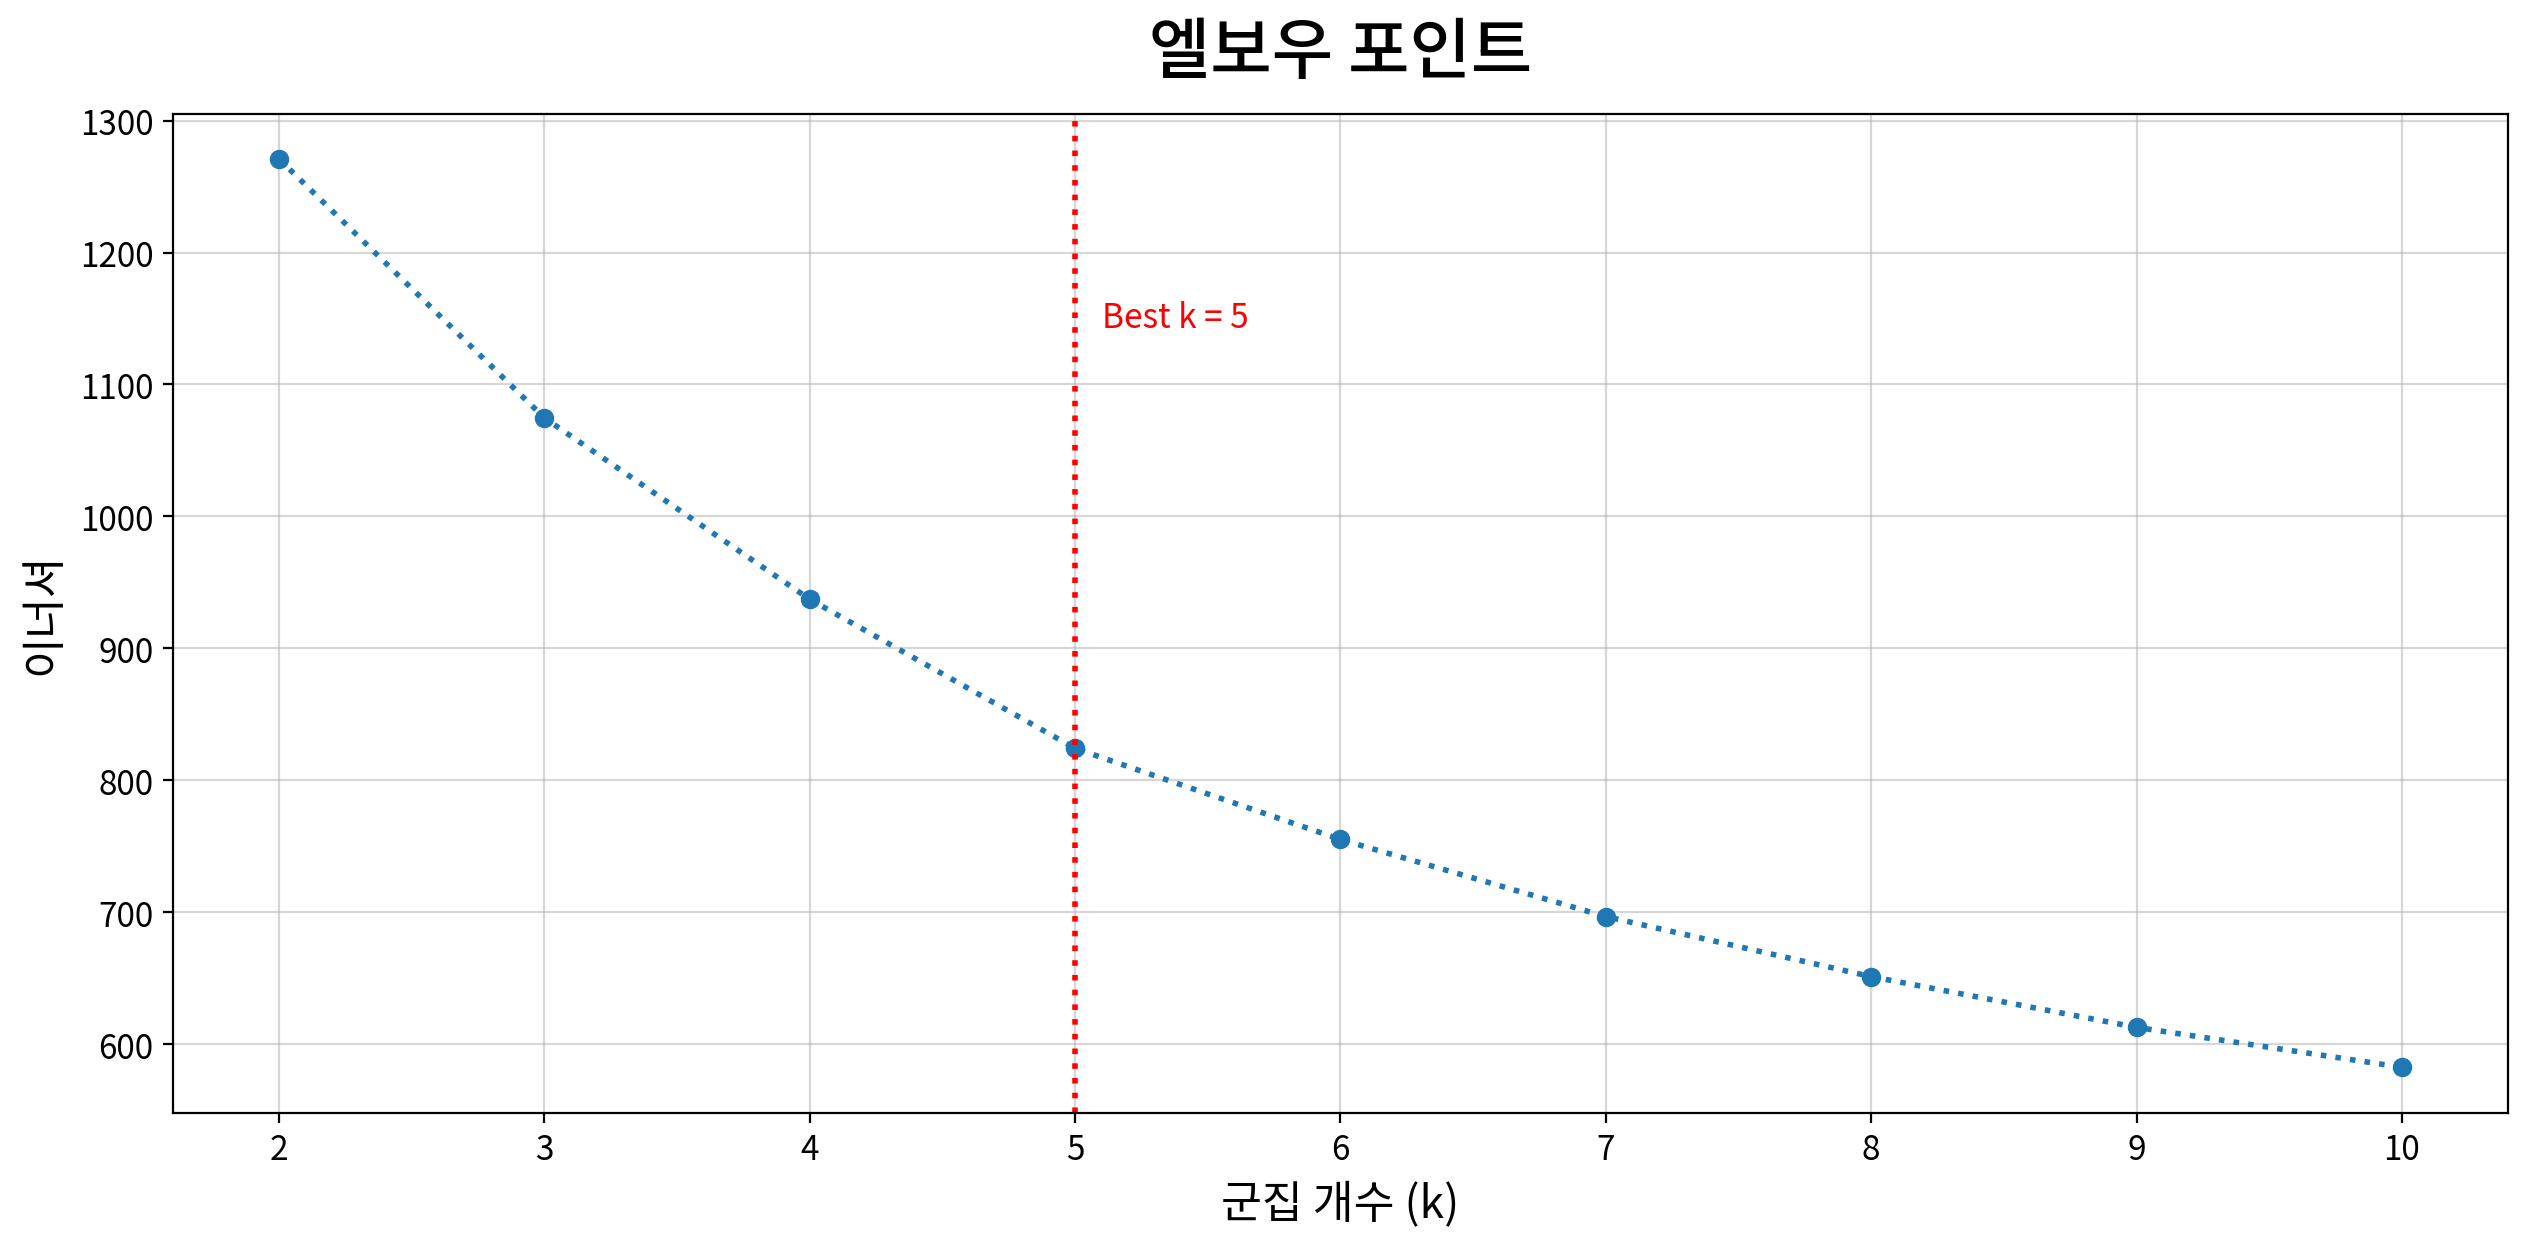

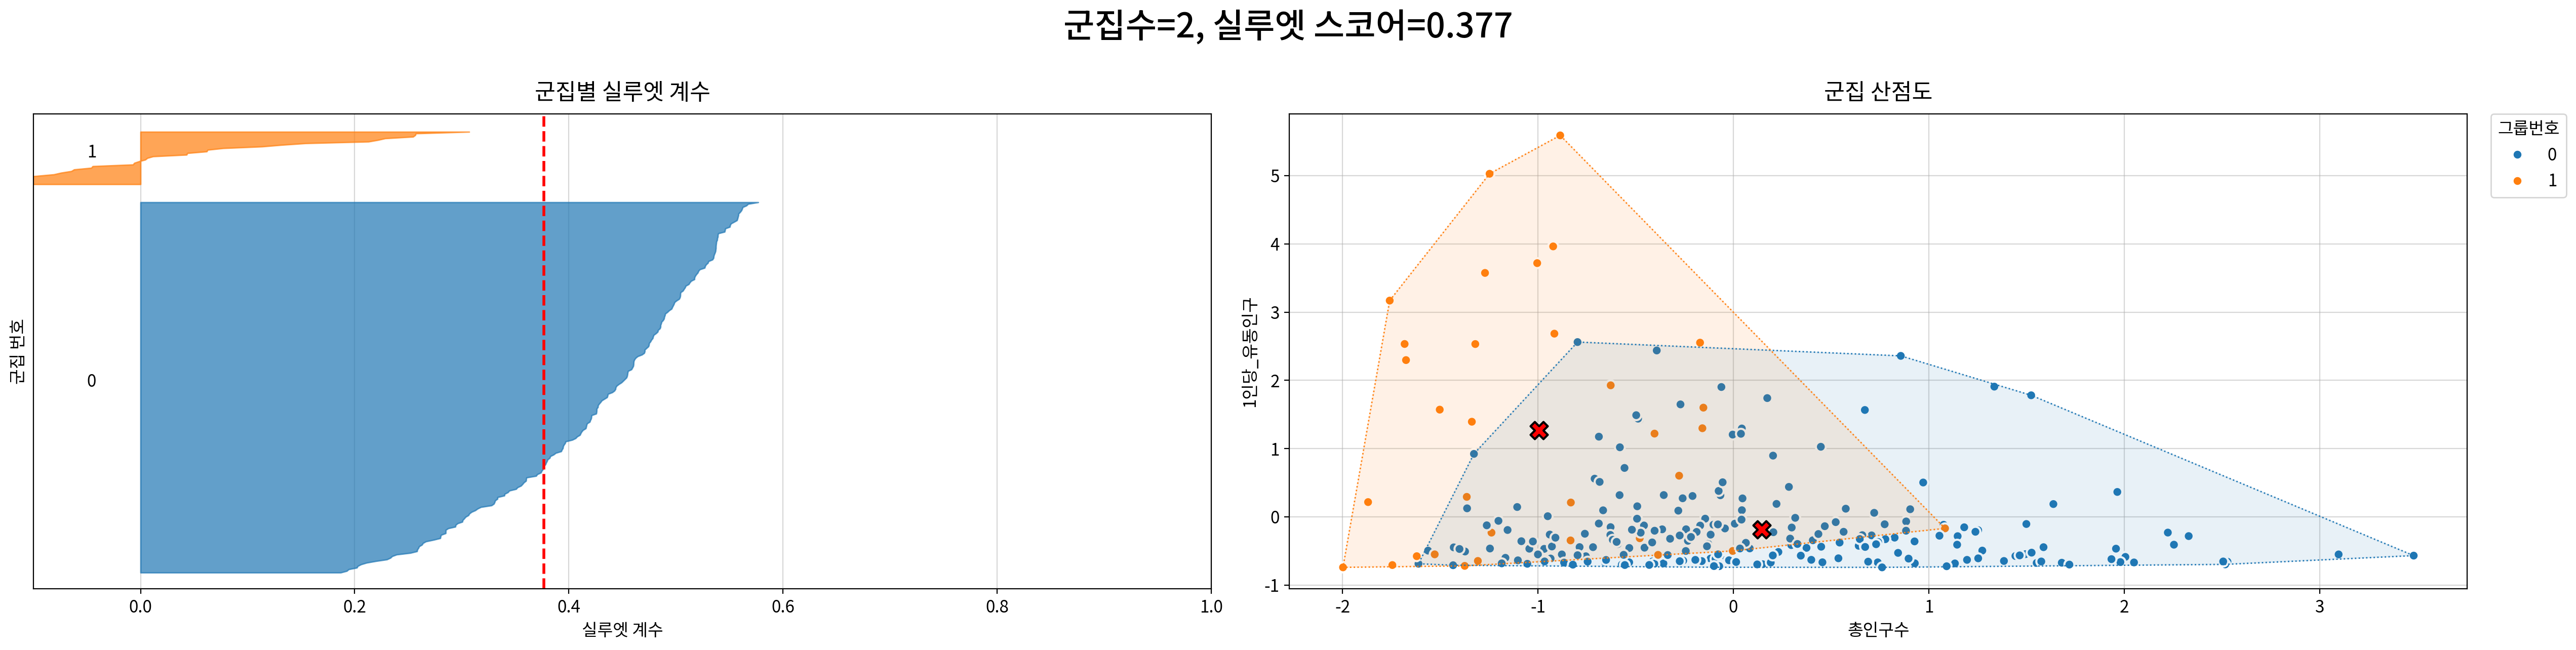

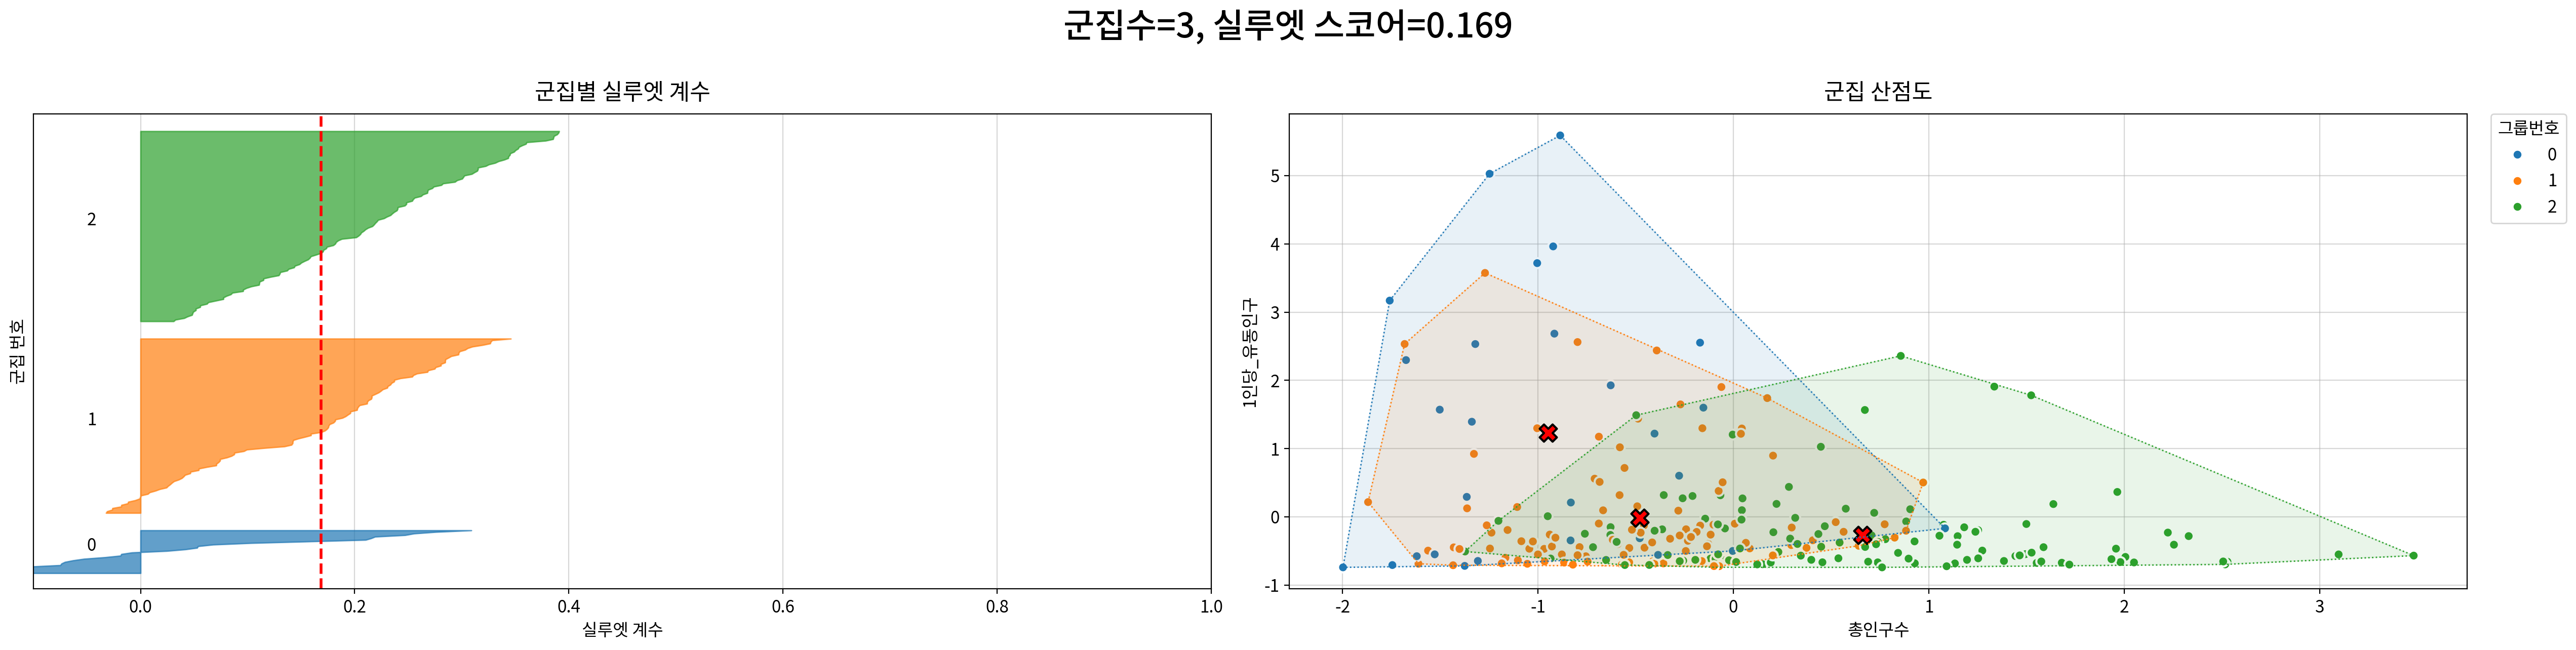

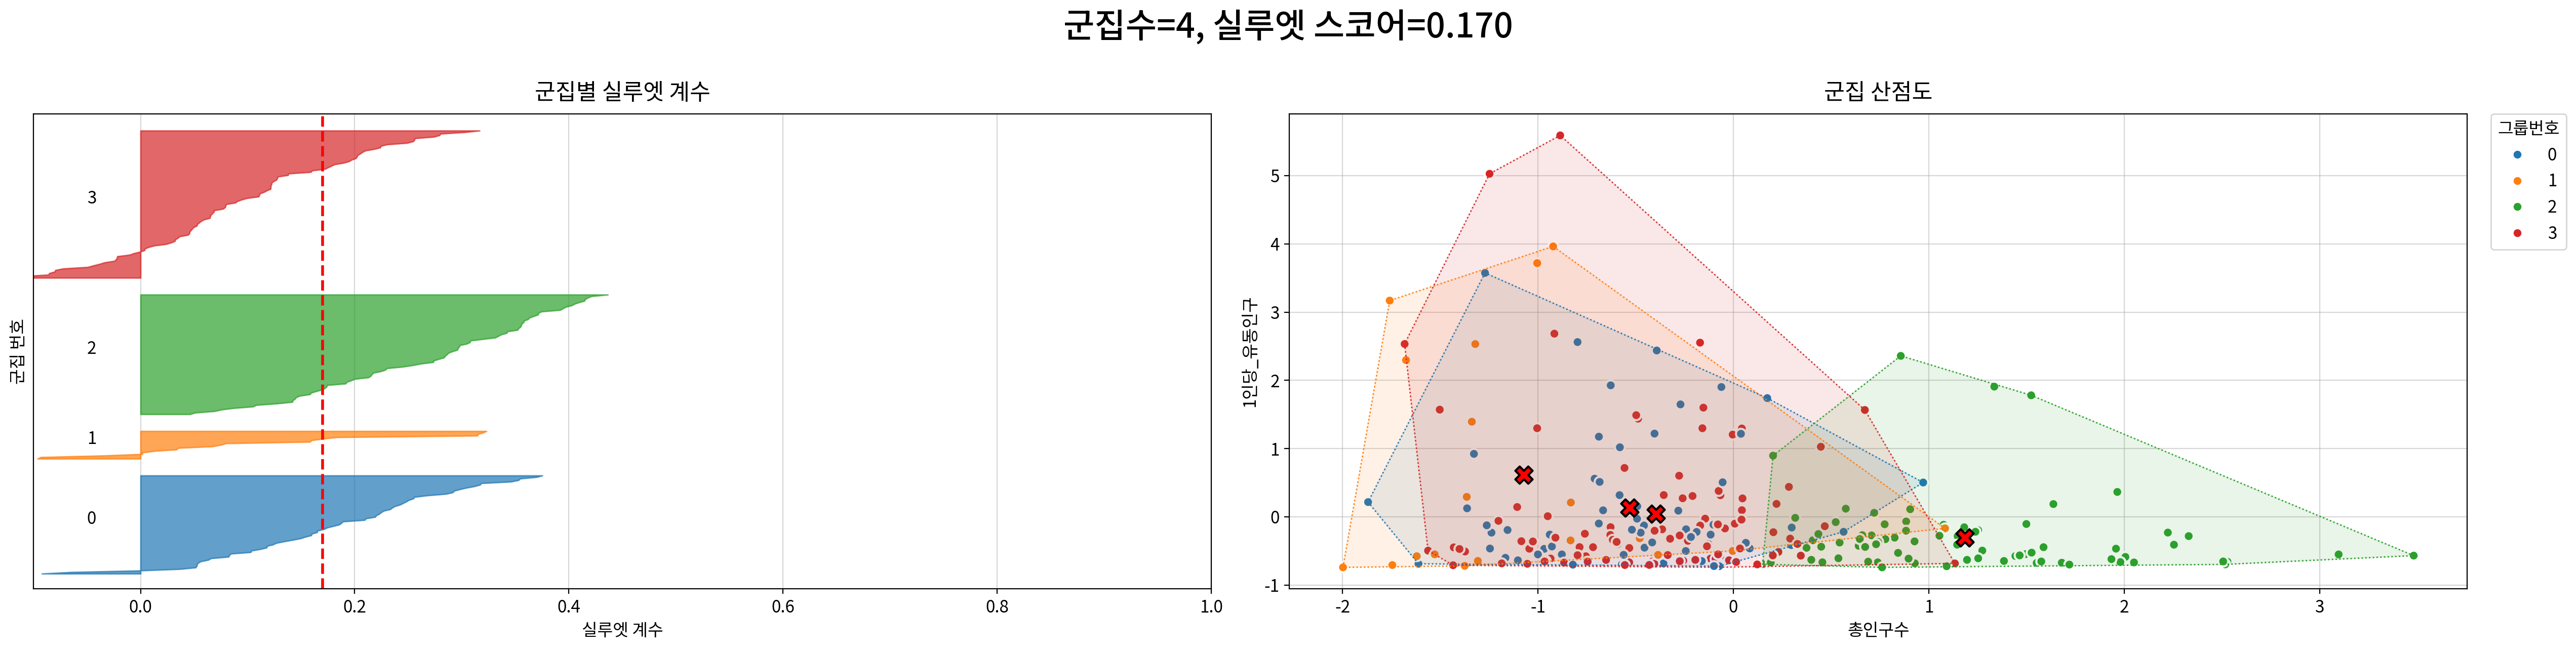

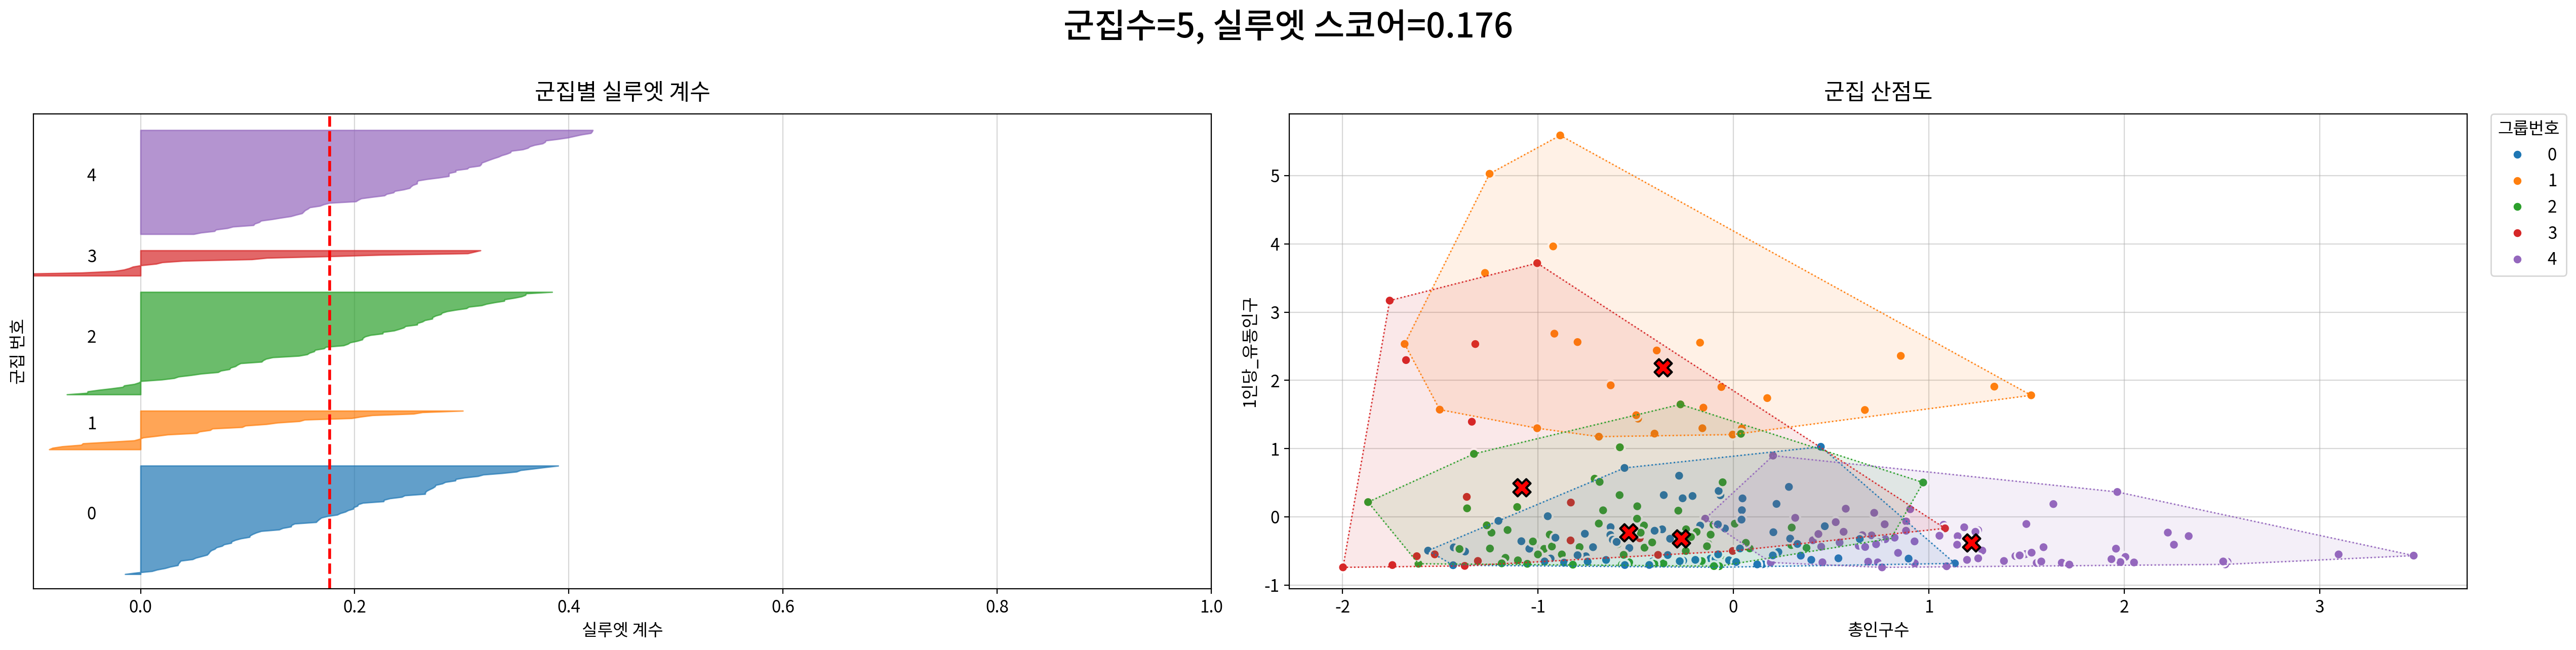

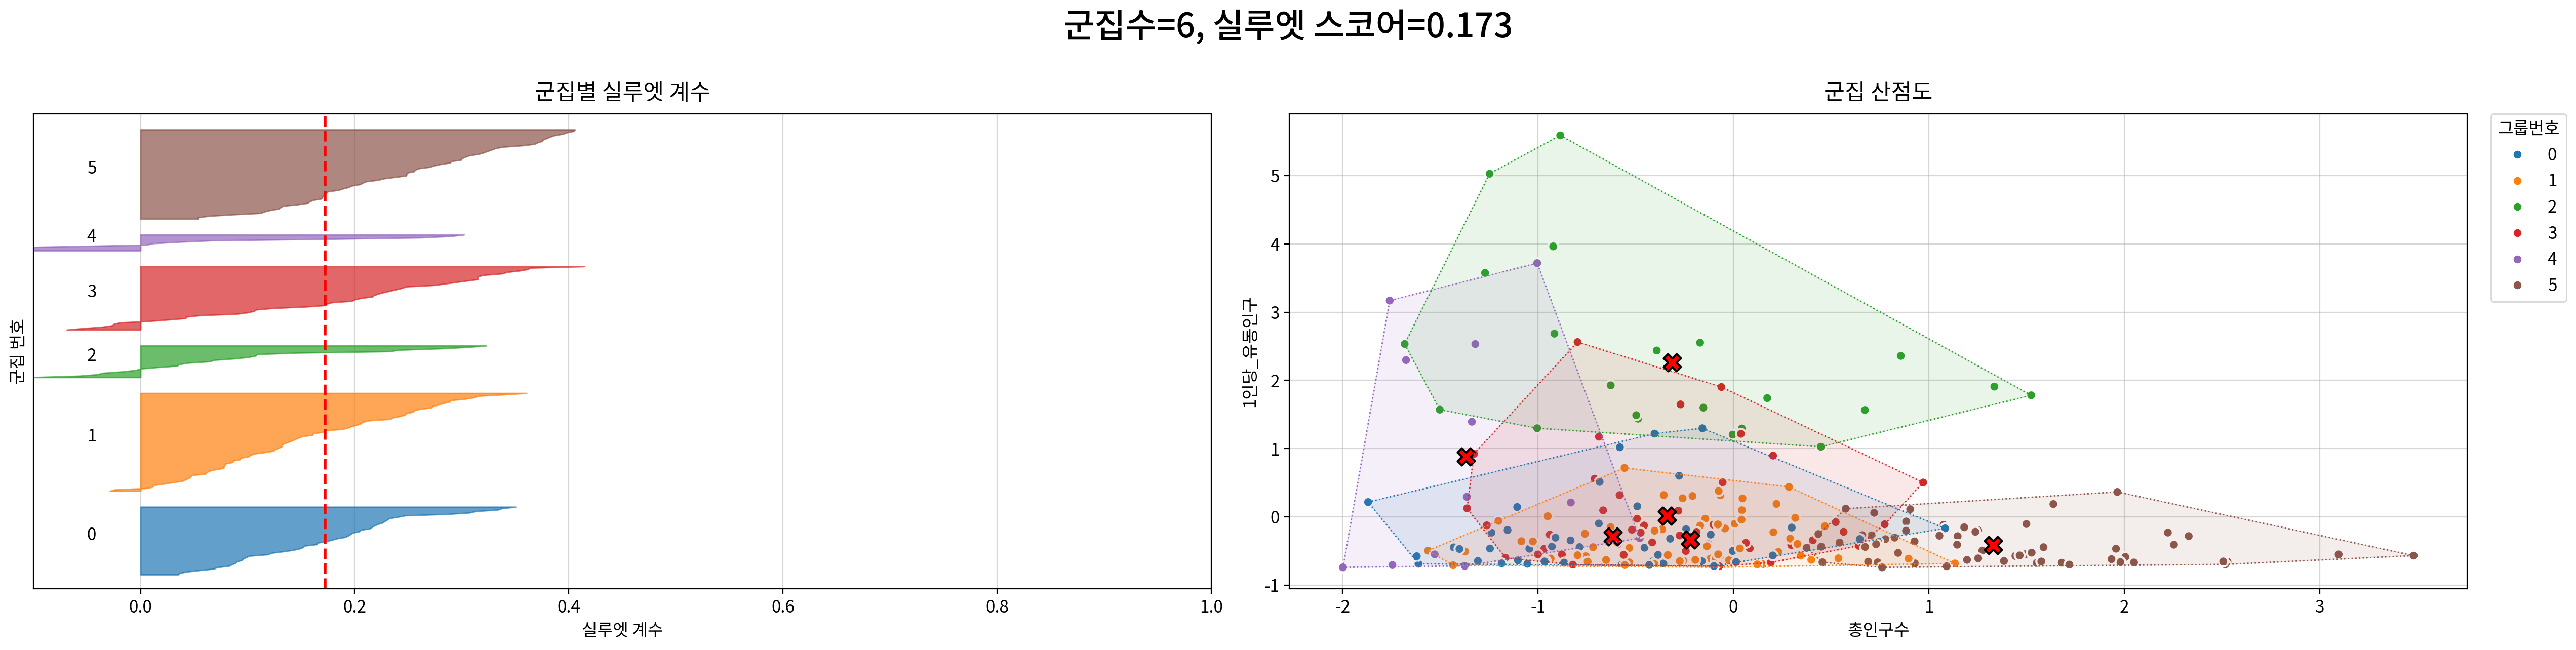

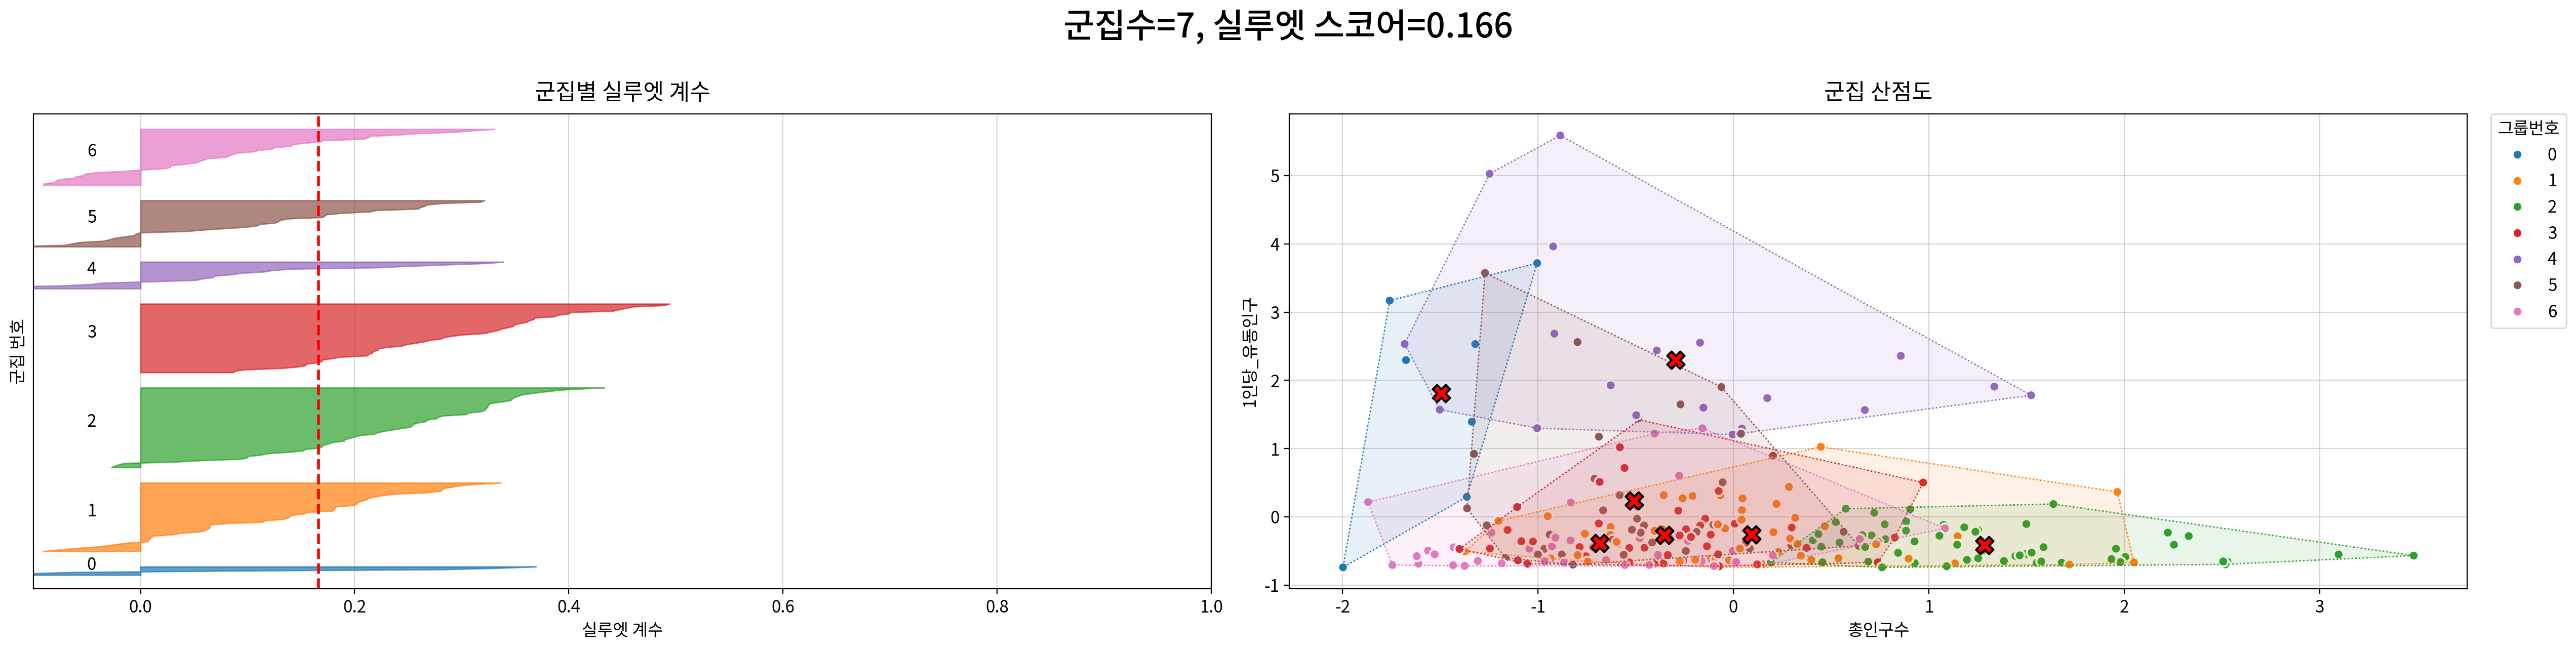

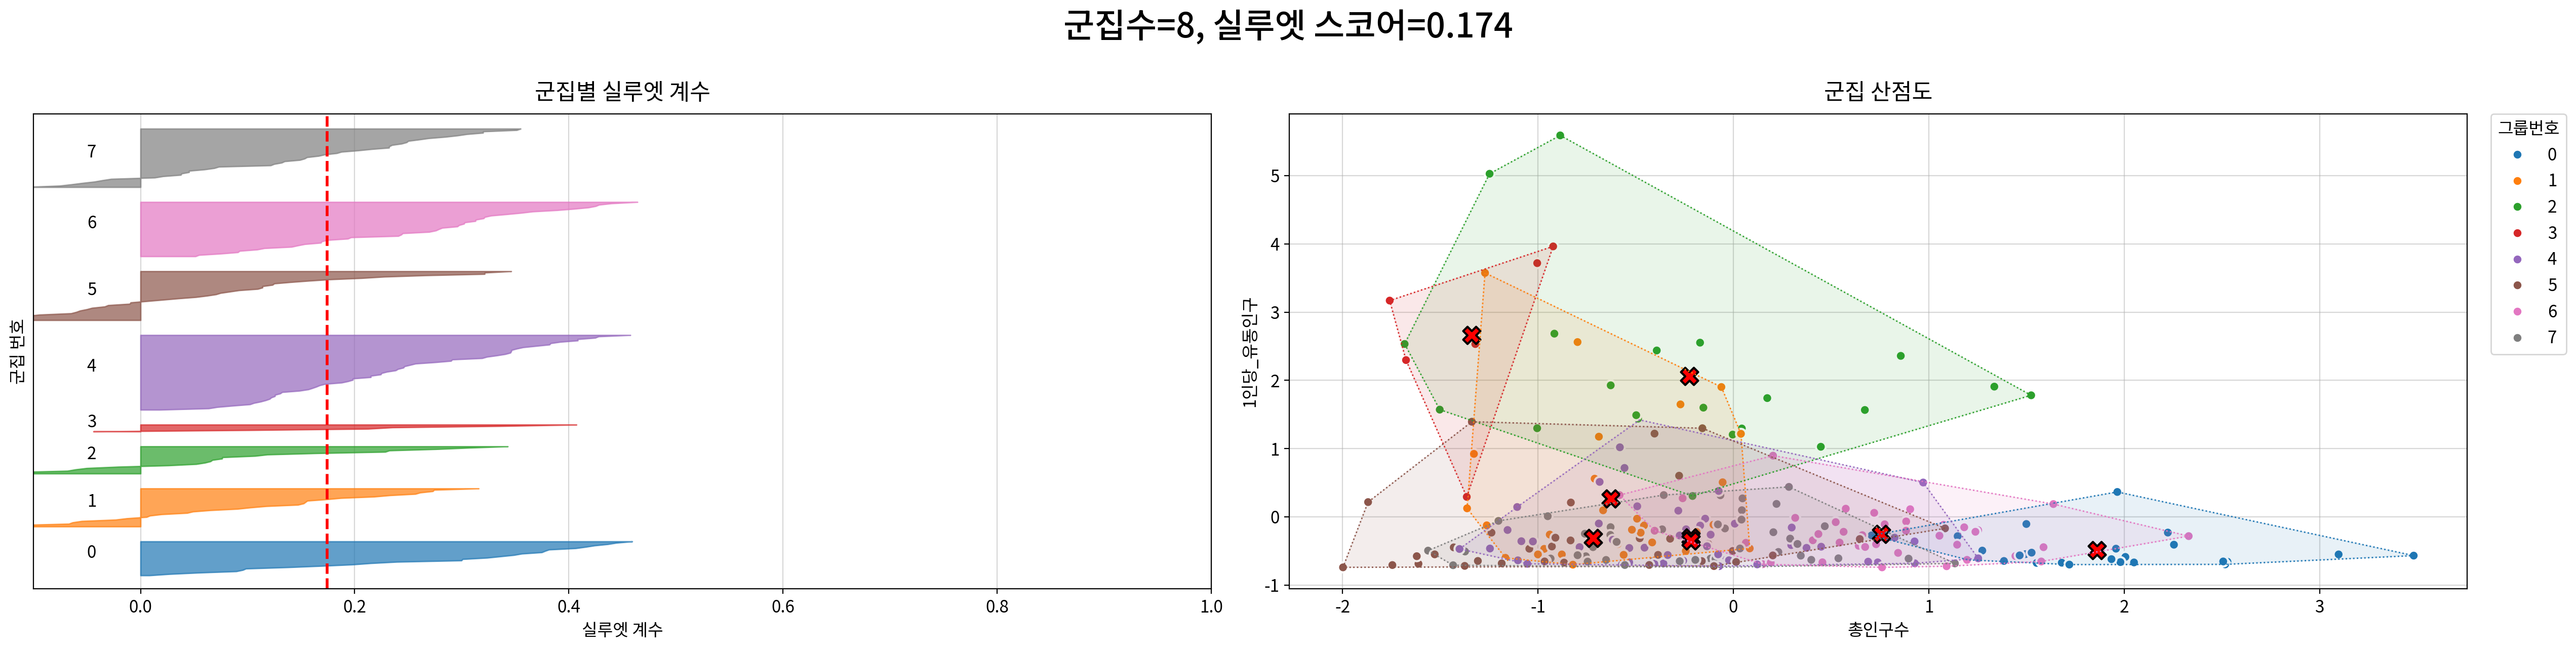

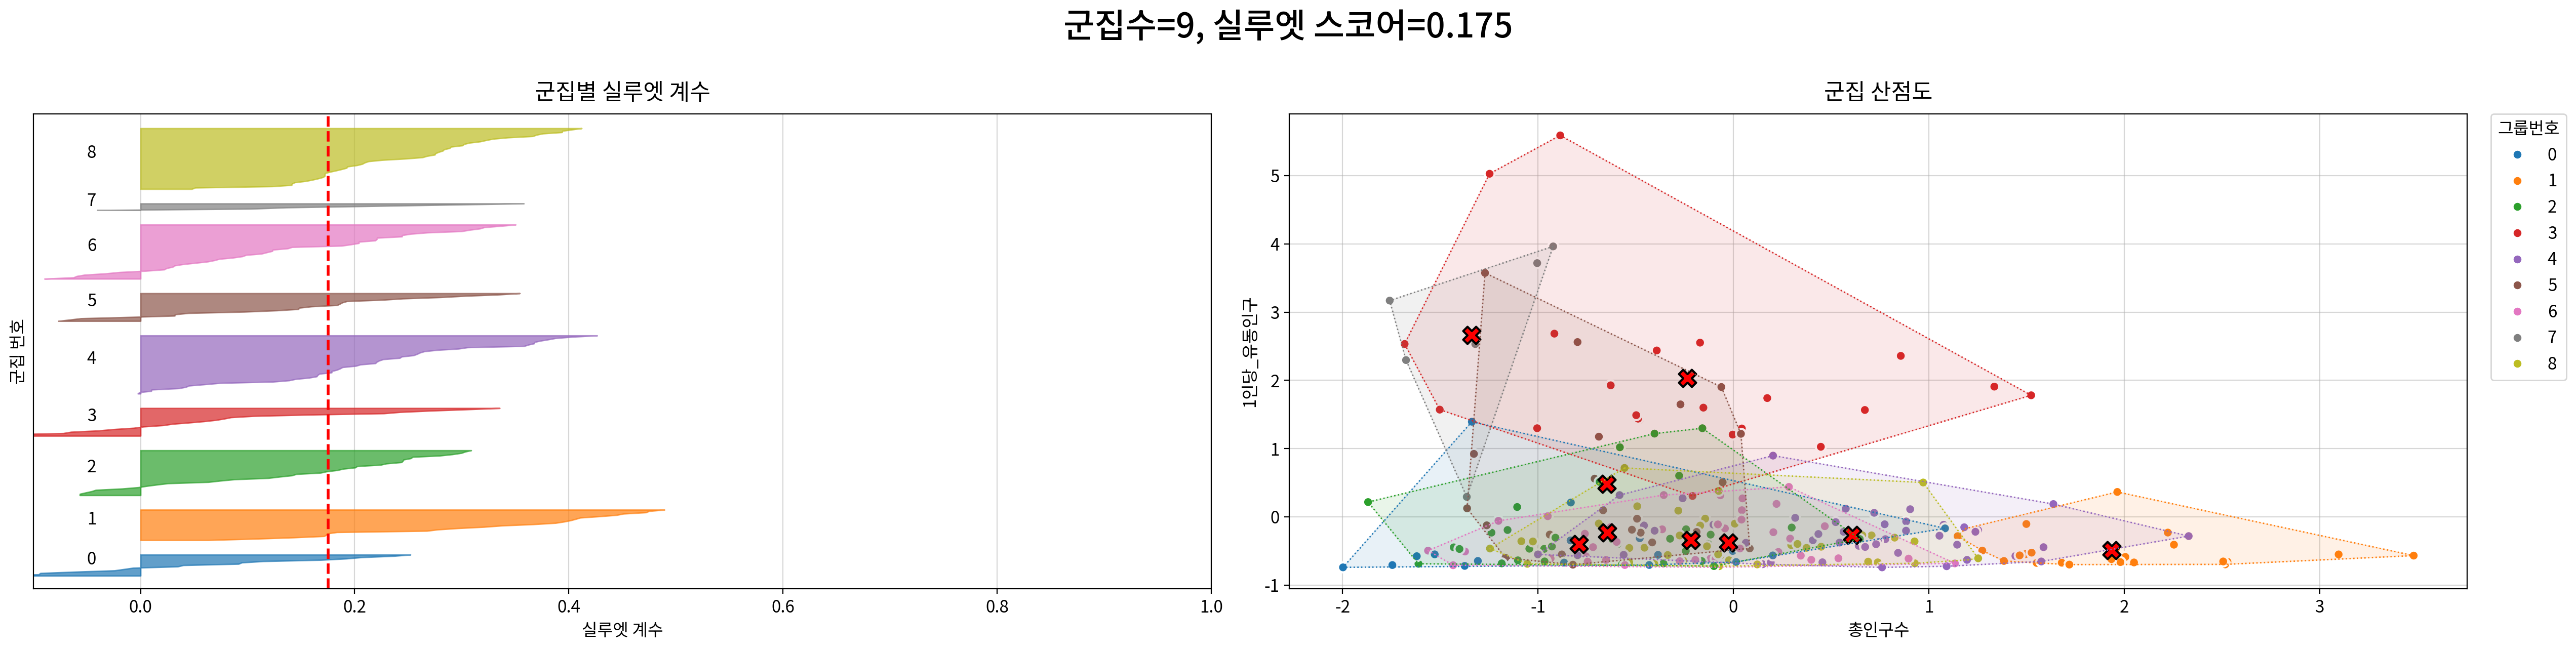

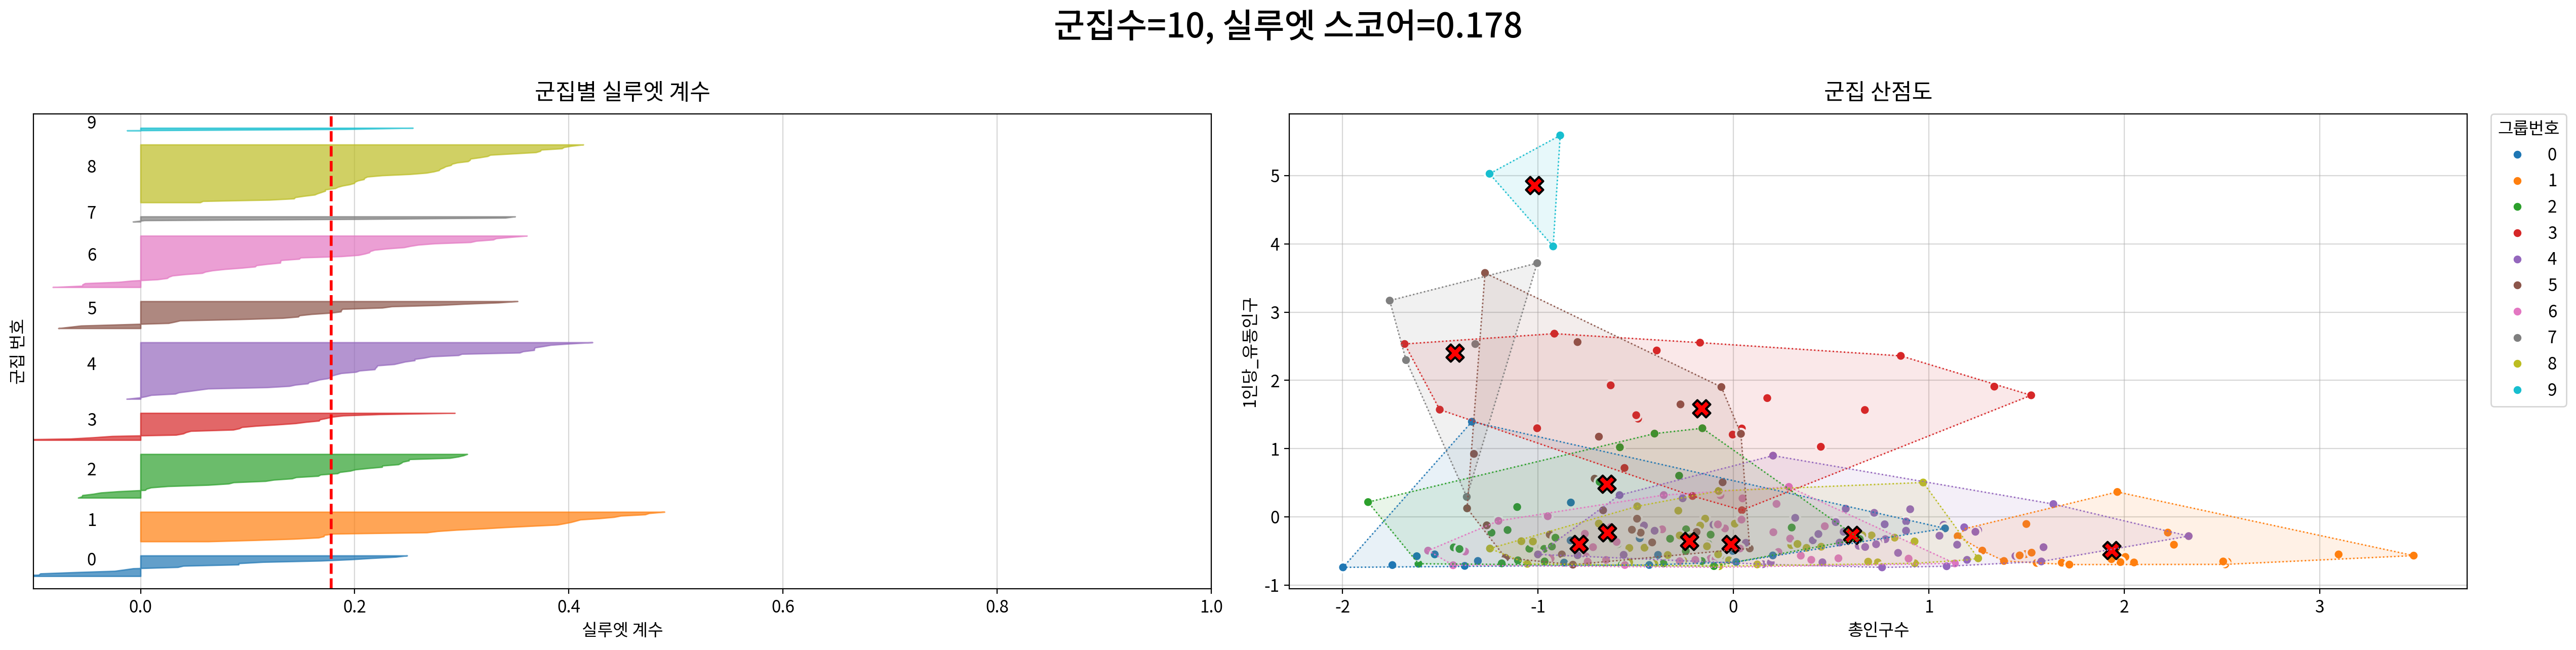

[1단계] 엘보우 포인트   : k = 5 (뭉침만 확인 → 후보)
[2단계] 실루엣 균형지수 : k = 4 (뭉침 + 분리 + 크기 균형)
------------------------------------------------------------
두 지표가 다른 k를 가리킵니다.
  · k = 5: 균형지수 0.0057 (스코어 0.1764, 두께비 4.1111)
  · k = 4: 균형지수 0.0061 (스코어 0.1701, 두께비 5.1053)
------------------------------------------------------------
>>> 최종 선택: k = 4
    (지표는 후보를 좁혀줄 뿐이므로, 목적과 도메인 지식으로 한 번 더 확인할 것)


(4,
     k        이너셔       감소량     스코어     전체면적      두께비  최소상대면적    균형지수
 0   2  1270.8610       NaN  0.3765  97.8901   6.8788  0.0243  0.0013
 1   3  1074.6010  196.2600  0.1686  43.8360   4.3214  0.0637  0.0025
 2   4   937.1179  137.4831  0.1701  44.2245   5.1053  0.1832  0.0061
 3   5   824.1016  113.0163  0.1764  45.8682   4.1111  0.1337  0.0057
 4   6   755.0414   69.0602  0.1726  44.8688   5.7500  0.0775  0.0023
 5   7   696.6271   58.4143  0.1664  43.2762   8.2857  0.1270  0.0026
 6   8   651.0959   45.5312  0.1744  45.3324   9.3333  0.2201  0.0041
 7   9   612.6314   38.4646  0.1751  45.5321   7.8333  0.1961  0.0044
 8  10   582.3803   30.2511  0.1779  46.2527  15.3333  0.0934  0.0011)

In [22]:
my_cluster.best_k(
    df_area,
    columns=["총인구수", "1인당_유동인구", "만명당_가맹점수", "소매_비율", "음식_비율", "수리·개인_비율"],
    plot_each=True
)

### 군집 수 탐색 결과의 해석

- 엘보우 기준은 5개, 함수의 실루엣 균형지수는 4개 군집을 제시해 두 기준이 일치하지 않았다.
- 4개와 5개 군집의 실루엣 점수는 각각 약 0.170과 0.176이다. 이 차이만으로 5개가 명확하게 우월하다고 판단하기는 어렵다.
- 군집 수는 지표뿐 아니라 지역별 특성이 해석 가능하게 구분되는지도 함께 고려해야 한다. 이후 프로파일은 실제 선택된 5개 군집을 기준으로 읽는다.

In [23]:
final_k = 5

# 우편번호 70개 대신, 좌표 두 개로 4개 권역을 만든다.
estimator, cdf, _ = my_cluster.kmeans(df_area, k=final_k, columns=["총인구수", "1인당_유동인구", "만명당_가맹점수", "소매_비율", "음식_비율", "수리·개인_비율"], plot=False)

df_area["spatial_cluster"] = cdf["그룹번호"].astype("category")
column_means["spatial_cluster"] = "위경도 기반 공간 군집"


# 권역별 규모 · 평균 가격 · 중심 좌표
display(df_area.groupby("spatial_cluster", observed=True).agg(
            평균매출=("평균매출", "mean"),
        ).sort_values("평균매출", ascending=False))

StandardScaler 적용 (6개 컬럼)
컬럼                            변환 전                  변환 후
--------------------------------------------------------
총인구수          1547.62 ~ 68779.12          -2.00 ~ 3.48
1인당_유동인구           0.47 ~ 176.31          -0.74 ~ 5.59
만명당_가맹점수         35.30 ~ 1670.47          -1.35 ~ 6.83
소매_비율                0.16 ~ 0.55          -2.26 ~ 4.12
음식_비율                0.12 ~ 0.50          -3.29 ~ 2.52
수리·개인_비율             0.03 ~ 0.20          -3.89 ~ 2.26


,평균매출
spatial_cluster,
3,4.293481e+07
4,2.210838e+07
2,2.165622e+07
0,1.169077e+07
1,6.377454e+06


In [24]:
cluster_profile = df_area.groupby(
    "spatial_cluster", observed=True
).agg(
    행정동수=("행정동코드", "nunique"),
    총인구수=("총인구수", "mean"),
    만명당_가맹점수=("만명당_가맹점수", "mean"),
    인당_유동인구=("1인당_유동인구", "mean"),
    소매_비율=("소매_비율", "mean"),
    음식_비율=("음식_비율", "mean"),
    수리·개인_비율=("수리·개인_비율", "mean"),
)

display(cluster_profile.round(2))

,행정동수,총인구수,만명당_가맹점수,인당_유동인구,소매_비율,음식_비율,수리·개인_비율
spatial_cluster,,,,,,,
0,74,22779.32,309.20,12.15,0.28,0.39,0.13
1,27,21630.00,338.71,81.86,0.28,0.34,0.14
2,70,19491.14,226.86,14.67,0.34,0.29,0.15
3,18,12777.15,816.62,33.06,0.40,0.36,0.09
4,71,41006.09,235.04,10.51,0.26,0.32,0.14


### 군집별로 구분되는 인구와 가맹점 구조

- 군집 0은 음식 가맹점 비율이 가장 높고, 군집 2는 수리·개인 비율이 가장 높으며 소매 비율도 상대적으로 높다. 두 유형은 업종 구성에서 차이를 보인다.
- 군집 1은 주민등록인구 대비 유동인구가 가장 높다. 거주인구 규모만으로 설명되지 않는 유동 특성을 가진 유형으로 구분된다.
- 군집 3은 인구 대비 가맹점 수와 소매 비율이 가장 높고, 평균 주민등록인구는 가장 적다. 가맹점이 주민 규모에 비해 많이 분포하는 유형이다.
- 군집 4는 평균 주민등록인구가 가장 많지만 인구 대비 유동인구는 가장 낮다. 큰 인구 규모와 높은 상대적 유동 수준이 같은 특성은 아니라는 점을 보여준다.

In [25]:
df_area.groupby("spatial_cluster", observed=True).agg(
    행정동수=("행정동코드", "size"),
    평균=("평균매출", "mean"),
    중앙값=("평균매출", "median"),
    표준편차=("평균매출", "std"),
    최댓값=("평균매출", "max"),
).round(2)

,행정동수,평균,중앙값,표준편차,최댓값
spatial_cluster,,,,,
0,74,11690774.31,4138225.21,4.255272e+07,3.551801e+08
1,27,6377453.83,4430300.33,5.788165e+06,2.155663e+07
2,70,21656218.71,2873469.08,6.666294e+07,3.996625e+08
3,18,42934807.97,5847218.27,1.374768e+08,5.875862e+08
4,71,22108379.20,8209121.88,6.475681e+07,5.008860e+08


### 군집의 평균매출 순위와 대표적인 매출 수준은 다르다

- 군집 3은 평균매출의 평균이 가장 높지만, 행정동별 평균매출의 중앙값은 군집 4가 가장 높다. 평균 순위만으로 군집 전체의 매출 수준을 설명하기 어렵다.
- 군집 2와 4는 평균이 비슷하지만 중앙값은 상당히 다르다. 평균만 비교하면 군집 내부의 매출 분포 차이를 놓칠 수 있다.
- 인구 대비 유동인구가 가장 높은 군집 1의 평균매출은 가장 낮다. 높은 상대적 유동 수준이 높은 지역화폐 매출로 그대로 연결되지는 않는다.
- 이후 군집별 매출 검증과 정책적 해석에서는 평균뿐 아니라 군집 내부 편차와 개별 행정동의 특성을 함께 확인한다.

In [26]:
# 05. 공간특성 반영
## 3. 공간 특성 반영 파생변수 추가
target = "평균매출"
df_area["spatial_cluster"] = cdf["그룹번호"].astype("category")

# #02 와 같은 규칙으로 의미를 등록하고 목록 이름을 붙인다.
# -> #04의 검증 반복문이 이 이름을 그대로 받아 쓴다.
column_means["spatial_cluster"] = "위경도 기반 공간 군집"
people_cols = ["spatial_cluster"]

df_area[["spatial_cluster", "행정동코드"]].head()

,spatial_cluster,행정동코드
0,2,4111156000
1,4,4111156600
2,4,4111157100
3,2,4111157200
4,4,4111157300


In [27]:
cols = df_area.columns.tolist()
cols.remove("spatial_cluster")
cols.insert(cols.index("행정동코드") + 1, "spatial_cluster")

df_area = df_area[cols]

df_area.head()

,행정동코드,spatial_cluster,행정구역,총인구수,월유동인구수,소매_비율,숙박_비율,음식_비율,부동산_비율,과학·기술_비율,...,예술·스포츠_비율,수리·개인_비율,기타_비율,총_가맹점수,1인당_유동인구,만명당_가맹점수,평균매출,위도,경도,서울중심지_거리_km
0,4111156000,2,경기도 수원시 장안구 파장동,24479.416667,2.465431e+05,0.377449,0.003344,0.341137,0.001433,0.009556,...,0.032489,0.128046,0.028667,697.666667,10.071444,285.001345,2.309790e+06,37.320531,126.989378,27.378798
1,4111156600,4,경기도 수원시 장안구 율천동,40142.208333,5.287070e+05,0.216046,0.002404,0.402644,0.002404,0.007212,...,0.061899,0.145132,0.028245,1109.333333,13.170850,276.350848,6.843445e+06,37.299592,126.971753,29.695822
2,4111157100,4,경기도 수원시 장안구 정자1동,31046.958333,3.570282e+05,0.291217,0.004622,0.270416,0.000000,0.007704,...,0.035439,0.131741,0.030046,432.666667,11.499619,139.358794,4.337255e+06,37.304703,126.989323,29.137576
3,4111157200,2,경기도 수원시 장안구 정자2동,37978.750000,1.329960e+06,0.338695,0.006256,0.315460,0.001340,0.006702,...,0.029044,0.172922,0.030831,746.000000,35.018519,196.425633,4.340631e+06,37.292271,126.998383,30.555018
4,4111157300,4,경기도 수원시 장안구 정자3동,39261.500000,6.991828e+05,0.238992,0.000000,0.291002,0.001595,0.010530,...,0.051053,0.118698,0.018826,1044.666667,17.808357,266.079153,1.385744e+07,37.298399,126.984661,29.827806


### 지역 유형을 월별 분석과 연결

- 행정동별 군집을 월별 원 데이터에 연결하면 같은 지역 유형 안에서 시점별 매출과 인구 대비 가맹점 수준을 함께 비교할 수 있다.
- 군집은 여러 지역 특성을 요약한 범주이며, 매출의 높고 낮음을 직접 기준으로 만든 등급은 아니다.
- 이후 모델에서는 군집의 추가 예측 정보를 검토하고, 정책 해석에서는 유사한 지역을 비교하는 기준으로 활용한다. 두 역할은 구분해서 평가한다.

다음 EDA는 원본 분석의 반복이 아니라, 군집과 파생변수를 포함한 모델 입력 후보의 재검증 단계다.

In [28]:
df_area.to_excel("local_data4.xlsx", index=False)

In [29]:
df_area.head()

,행정동코드,spatial_cluster,행정구역,총인구수,월유동인구수,소매_비율,숙박_비율,음식_비율,부동산_비율,과학·기술_비율,...,예술·스포츠_비율,수리·개인_비율,기타_비율,총_가맹점수,1인당_유동인구,만명당_가맹점수,평균매출,위도,경도,서울중심지_거리_km
0,4111156000,2,경기도 수원시 장안구 파장동,24479.416667,2.465431e+05,0.377449,0.003344,0.341137,0.001433,0.009556,...,0.032489,0.128046,0.028667,697.666667,10.071444,285.001345,2.309790e+06,37.320531,126.989378,27.378798
1,4111156600,4,경기도 수원시 장안구 율천동,40142.208333,5.287070e+05,0.216046,0.002404,0.402644,0.002404,0.007212,...,0.061899,0.145132,0.028245,1109.333333,13.170850,276.350848,6.843445e+06,37.299592,126.971753,29.695822
2,4111157100,4,경기도 수원시 장안구 정자1동,31046.958333,3.570282e+05,0.291217,0.004622,0.270416,0.000000,0.007704,...,0.035439,0.131741,0.030046,432.666667,11.499619,139.358794,4.337255e+06,37.304703,126.989323,29.137576
3,4111157200,2,경기도 수원시 장안구 정자2동,37978.750000,1.329960e+06,0.338695,0.006256,0.315460,0.001340,0.006702,...,0.029044,0.172922,0.030831,746.000000,35.018519,196.425633,4.340631e+06,37.292271,126.998383,30.555018
4,4111157300,4,경기도 수원시 장안구 정자3동,39261.500000,6.991828e+05,0.238992,0.000000,0.291002,0.001595,0.010530,...,0.051053,0.118698,0.018826,1044.666667,17.808357,266.079153,1.385744e+07,37.298399,126.984661,29.827806
